# 📊 Multiple Linear Regression Practice

## 🧠 Objective
To understand and implement **Multiple Linear Regression** using Python and analyze how multiple independent variables affect a dependent variable.

---

## 📌 What is Multiple Linear Regression?

Multiple Linear Regression is a statistical technique used to model the relationship between **one dependent variable** and **two or more independent variables**.

---
📐 Formula:

Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ + ε

Y: Dependent variable
X₁, X₂, ..., Xₙ: Independent variables
β₀: Intercept
β₁, β₂, ..., βₙ: Coefficients
ε: Error term

---

## 🛠️ Steps to Perform Multiple Linear Regression

1. Import libraries  
2. Load dataset  
3. Explore data (EDA)  
4. Handle missing values  
5. Split dataset  
6. Train model  
7. Make predictions  
8. Evaluate model  

---

## 📦 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_index = pd.read_csv('economic_index.csv')
# drop the unnecessary columns
df_index.drop(columns=['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [3]:
#  to check for null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

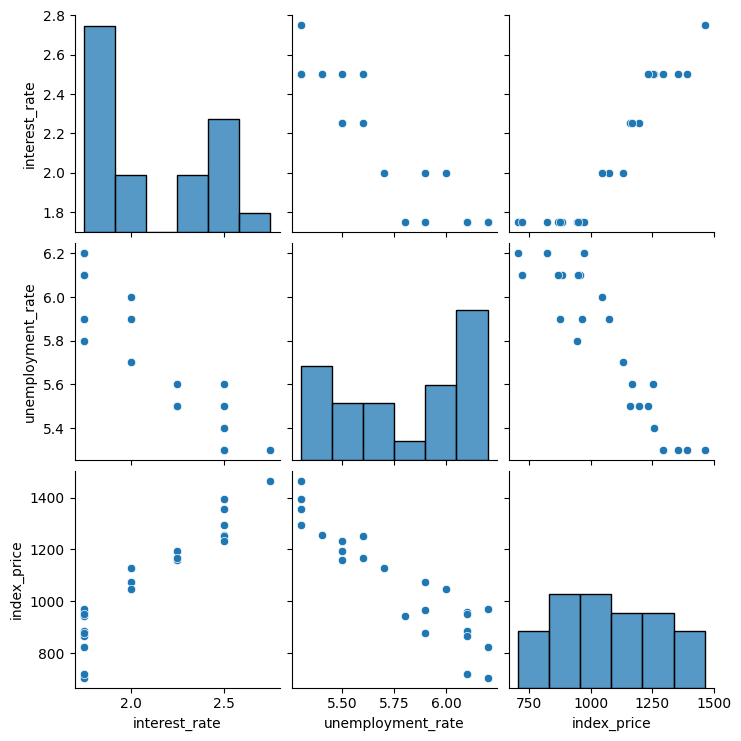

In [4]:
# visualization of the data
sns.pairplot(df_index)
plt.show()

In [5]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


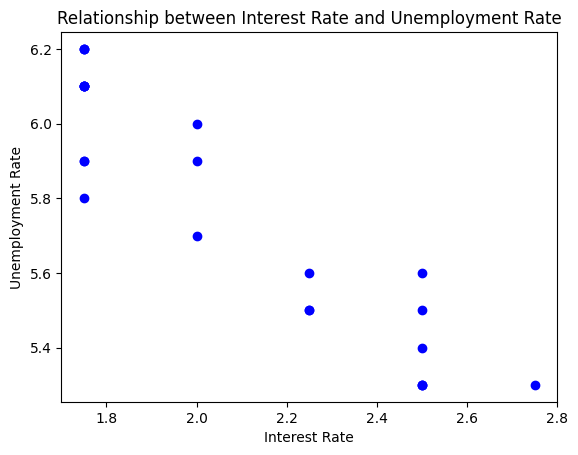

In [6]:
# visualize the datapoint more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='blue')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Relationship between Interest Rate and Unemployment Rate')
plt.show()

In [7]:
# independent and dependent features
X = df_index.iloc[:, :-1]
y = df_index.iloc[:, -1]

In [8]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

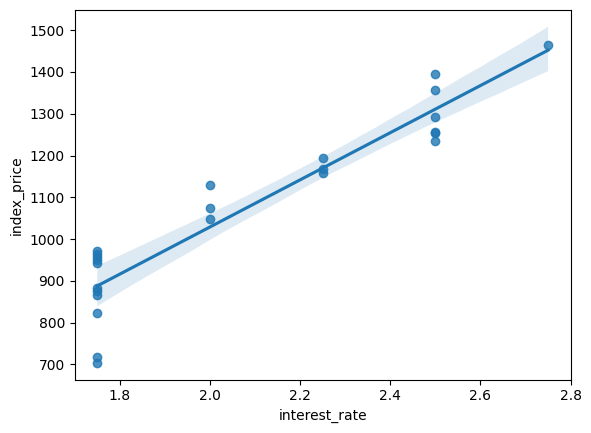

In [9]:
sns.regplot(x='interest_rate', y='index_price', data=df_index)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

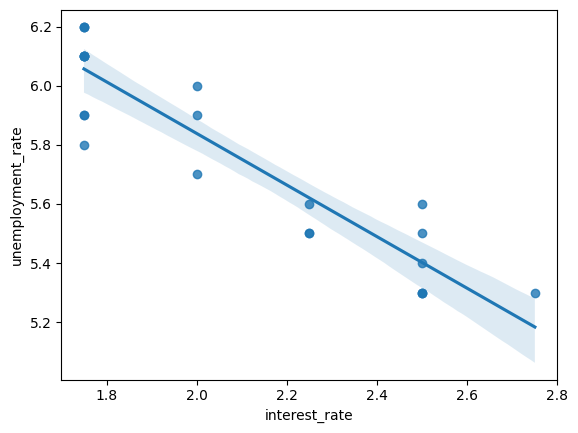

In [10]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)


In [11]:
# Standardization of the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# training the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# cross validation score
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=3)
print("Cross-validation scores:", np.mean(cv_scores))

Cross-validation scores: -5914.828180162386


In [14]:
# Prediction and evaluation
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Mean Squared Error: 5793.762887712569
R^2 Score: 0.8278978091457145


#### Assumptions

<Axes: xlabel='interest_rate', ylabel='index_price'>

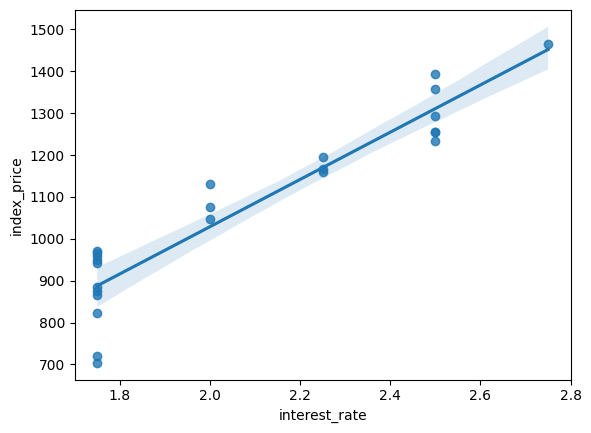

In [15]:
# Assumptions of linear regression
# 1. Linearity
sns.regplot(x='interest_rate', y='index_price', data=df_index)

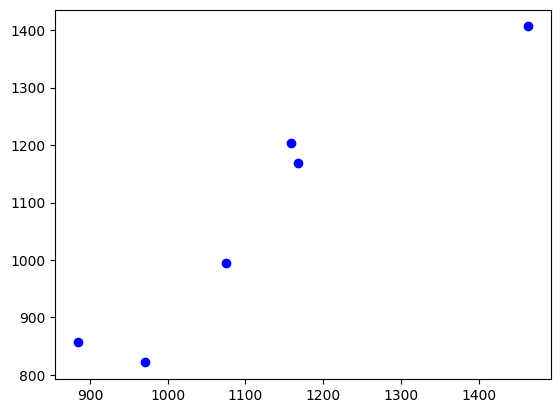

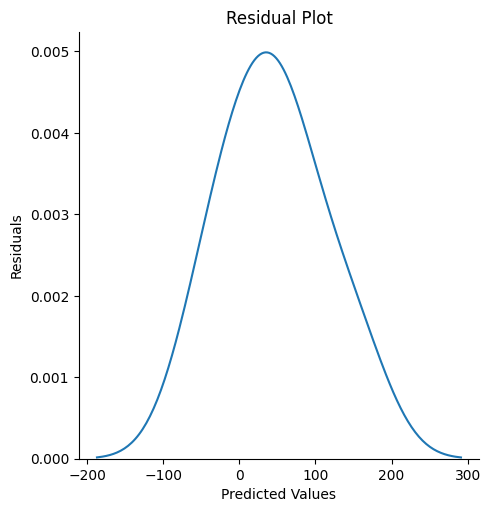

In [20]:
residuals = y_test - y_pred
sns.displot(residuals, kind='kde')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

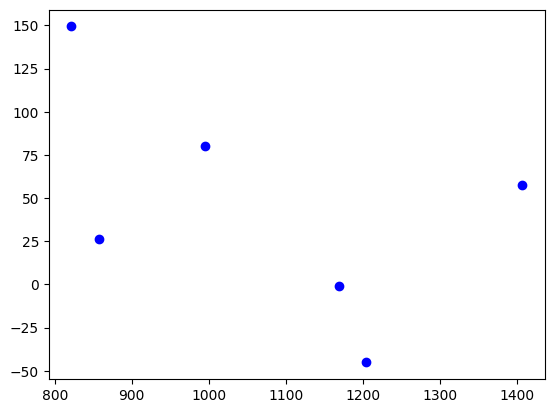

In [22]:
plt.scatter( y_pred, residuals, color='blue')

In [23]:
import pandas as pd
import statsmodels.api as sm

# Sample dataset
data = {
    "X1": [1, 2, 3, 4, 5],
    "X2": [2, 1, 3, 5, 4],
    "Y":  [5, 7, 9, 10, 12]
}

df = pd.DataFrame(data)

# Features and Target
X = df[["X1", "X2"]]
Y = df["Y"]

# Add intercept
X = sm.add_constant(X)

# Model
model = sm.OLS(Y, X).fit()

# Output
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     145.0
Date:                Thu, 09 Apr 2026   Prob (F-statistic):            0.00685
Time:                        18:25:34   Log-Likelihood:                0.95250
No. Observations:                   5   AIC:                             4.095
Df Residuals:                       2   BIC:                             2.923
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6000      0.346     10.392      0.0

c:\Users\dpk41\OneDrive\Docs\Udemy Python\python\venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [24]:
# New data (X1=6, X2=3)
new_data = pd.DataFrame({"const": [1], "X1": [6], "X2": [3]})

prediction = model.predict(new_data)

print("Prediction:", prediction)

Prediction: 0    14.1
dtype: float64
